In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      69%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.89
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import pickle
import time
import glob

import sys
sys.path.insert(0, "../..")
from shared import load_sweep_data, run_param_recovery, plot_param_estimate, setup_latex_matplotlib

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"delta_grad == 0\.0\. Check if the approximated function is linear\..*",
    category=UserWarning,
)

In [4]:
all_data, data_keys = load_sweep_data("x0")

Loaded 19 x0 values from addm_data_all_x0_20260223-124516.pkl


In [5]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

In [6]:
paras_true, paras_mle = run_param_recovery(all_data, num_data_list, mode="mle")

true params: [0.30, 0.50, 2.00, -1.80]
num_data:   100, mle: [0.28591, 0.54456, 2.00322, -1.77286]
num_data:   200, mle: [0.26655, 0.49772, 1.87313, -1.64833]
num_data:   400, mle: [0.21540, 0.49478, 2.06525, -1.84077]
num_data:   800, mle: [0.23159, 0.50020, 2.03056, -1.79873]
num_data:  1600, mle: [0.30561, 0.51253, 2.08491, -1.85687]
num_data:  3200, mle: [0.30487, 0.50545, 2.05124, -1.82318]
num_data:  6400, mle: [0.30862, 0.50181, 1.99879, -1.76958]
num_data: 12800, mle: [0.30086, 0.50062, 1.99199, -1.76291]
num_data: 25600, mle: [0.30355, 0.50100, 2.00622, -1.77817]

true params: [0.30, 0.50, 2.00, -1.60]
num_data:   100, mle: [0.35020, 0.57177, 1.88260, -1.44847]
num_data:   200, mle: [0.33032, 0.51595, 1.93972, -1.50971]
num_data:   400, mle: [0.33680, 0.48620, 1.94409, -1.53267]
num_data:   800, mle: [0.31713, 0.47760, 1.90637, -1.50148]
num_data:  1600, mle: [0.31731, 0.48976, 1.96551, -1.56625]
num_data:  3200, mle: [0.33422, 0.50255, 1.99968, -1.60016]
num_data:  6400, mle:

In [ ]:
_, paras_tada = run_param_recovery(all_data, num_data_list, mode="tada")

In [11]:
data_to_save = {
    "paras_true_arr": paras_true,
    "paras_mle_arr": paras_mle,
    "paras_tada_arr": paras_tada,
}
fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"
with open(fname, "wb") as f:
    pickle.dump(data_to_save, f)
print(f"Saved to {fname}")

In [8]:
# load results (if necessary)
result_files = sorted(glob.glob("tada_mle_result_*.pkl"))
results = pickle.load(open(result_files[-1], "rb"))
paras_true = results["paras_true_arr"]
paras_mle = results["paras_mle_arr"]
paras_tada = results["paras_tada_arr"]

In [9]:
setup_latex_matplotlib()

In [12]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=0, param_name=r"\eta",
    swept_idx=3, swept_name=r"x_0",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 0],
    xlim=(-1.85, 1.85), ylim=(0.1, 0.5),
)

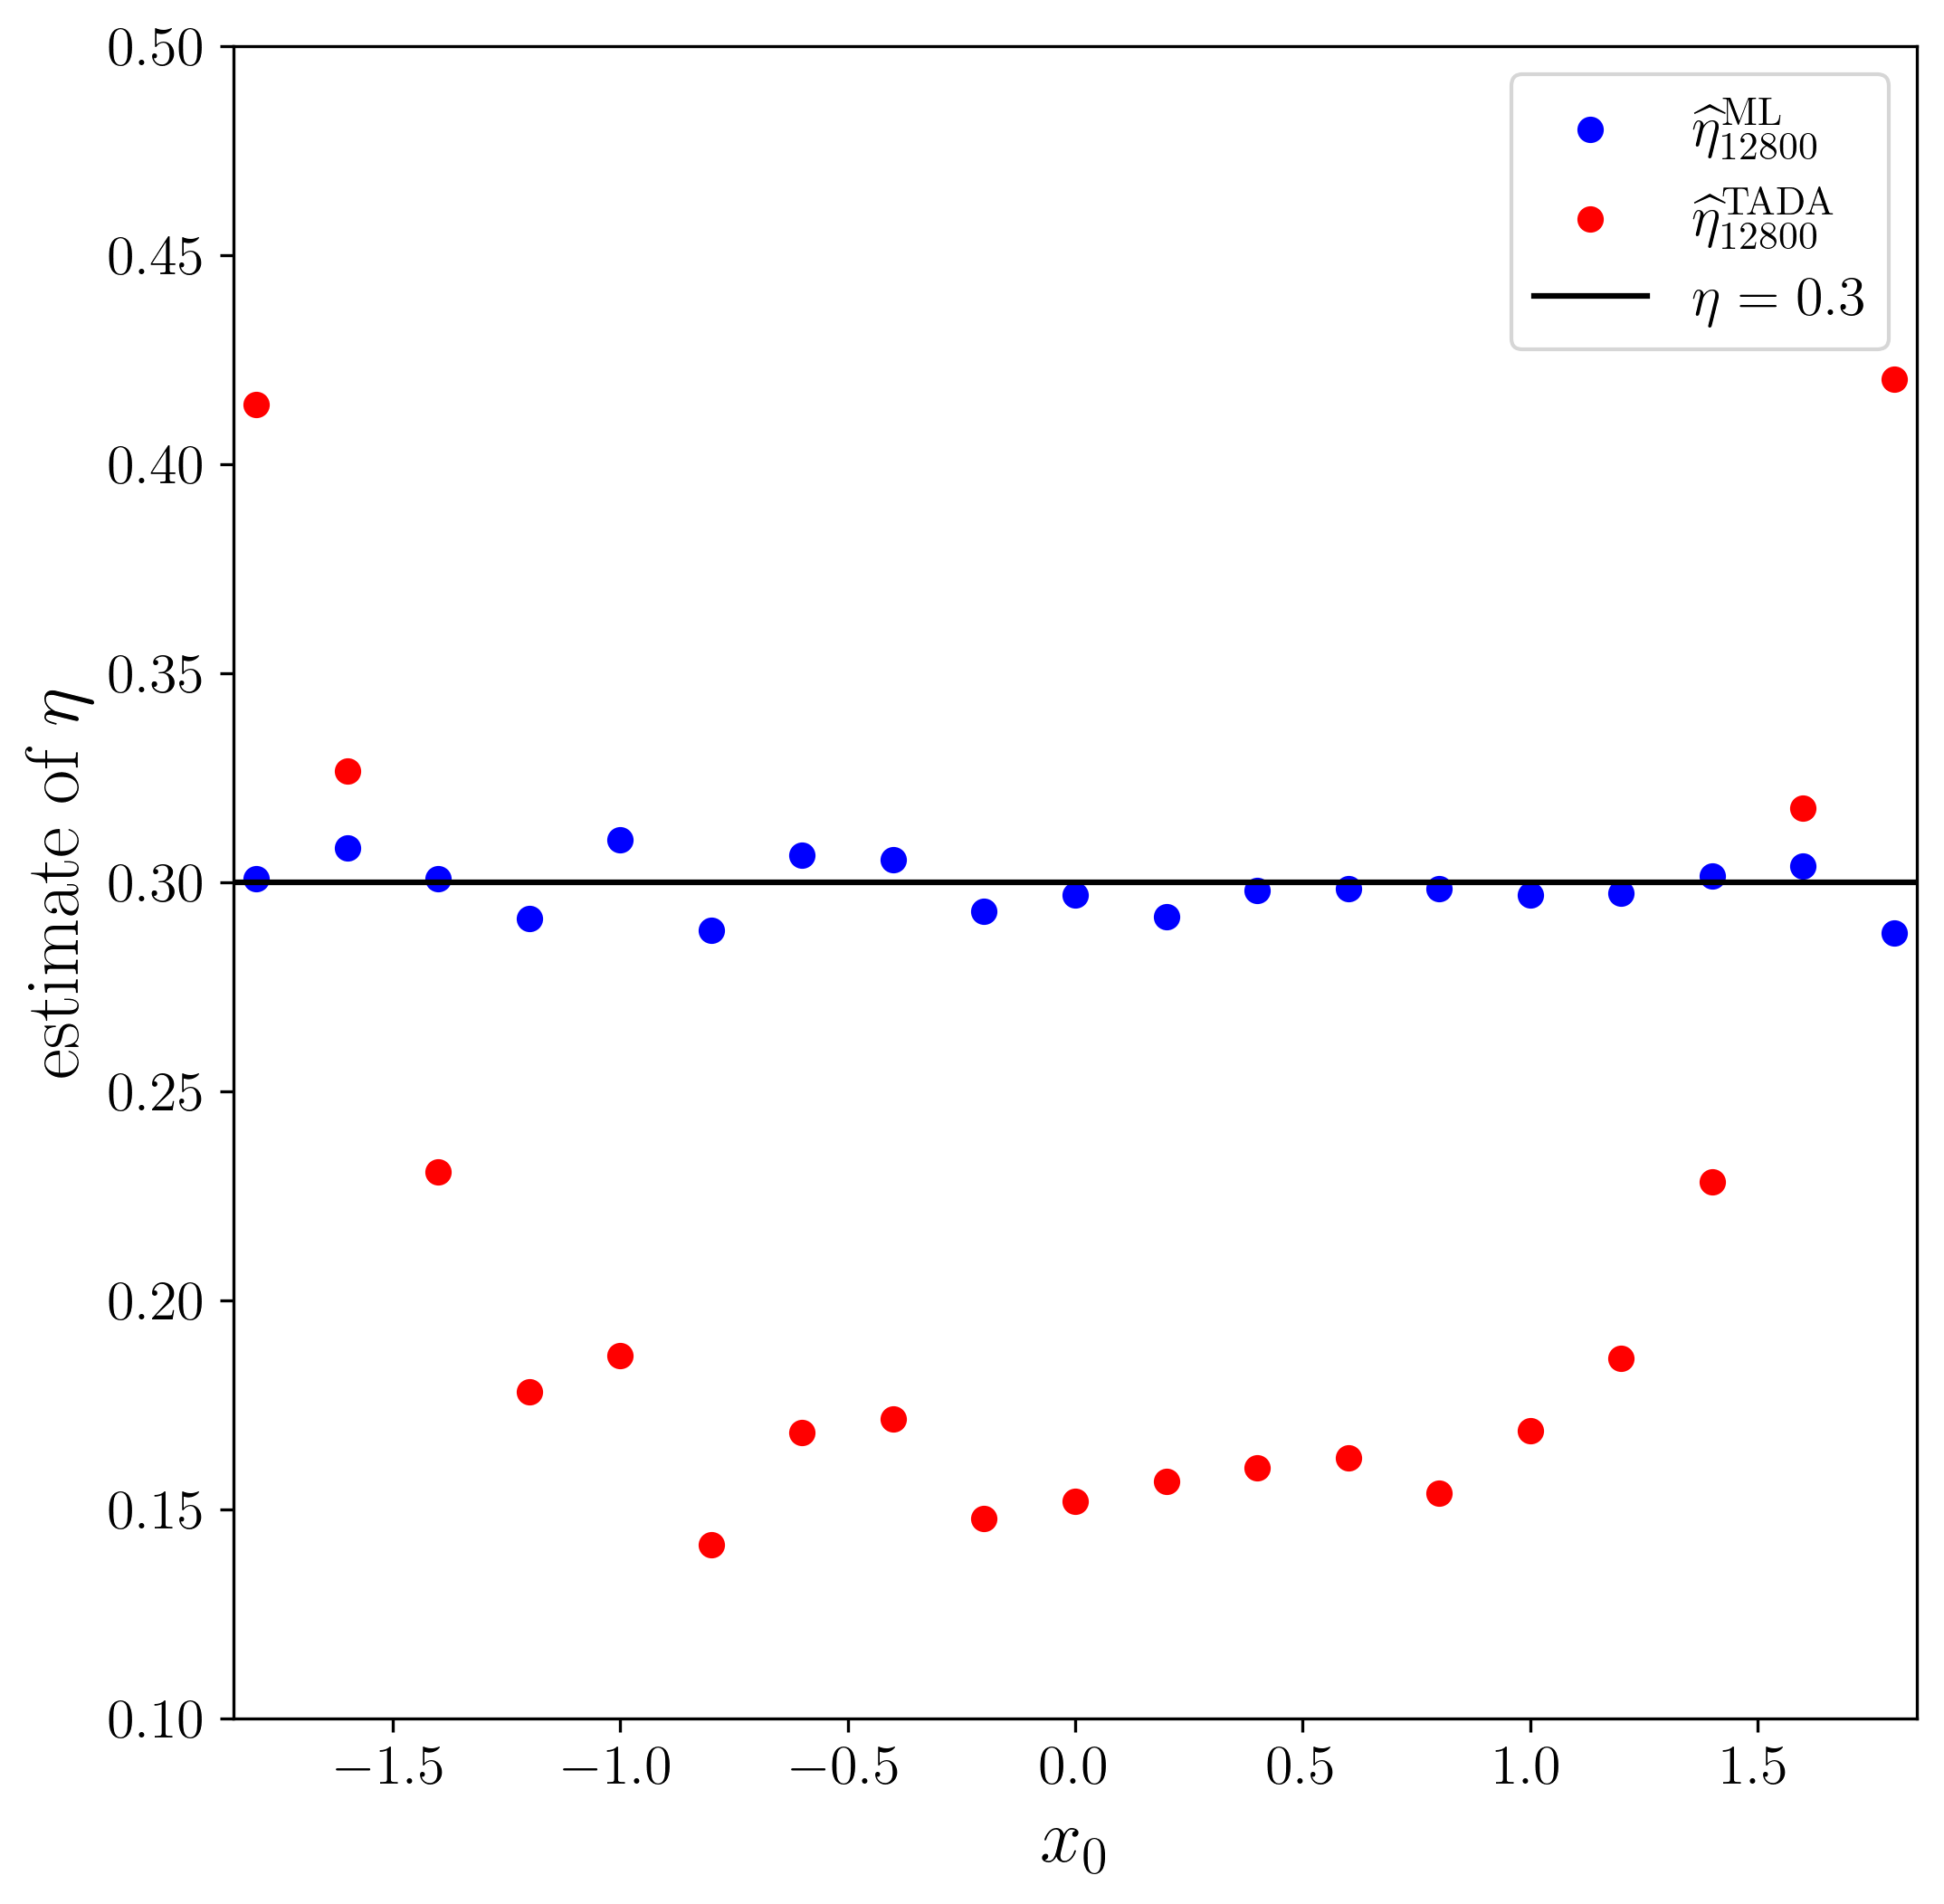

In [13]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=1, param_name=r"\kappa",
    swept_idx=3, swept_name=r"x_0",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 1],
    xlim=(-1.85, 1.85), ylim=(0.4, 0.6),
)

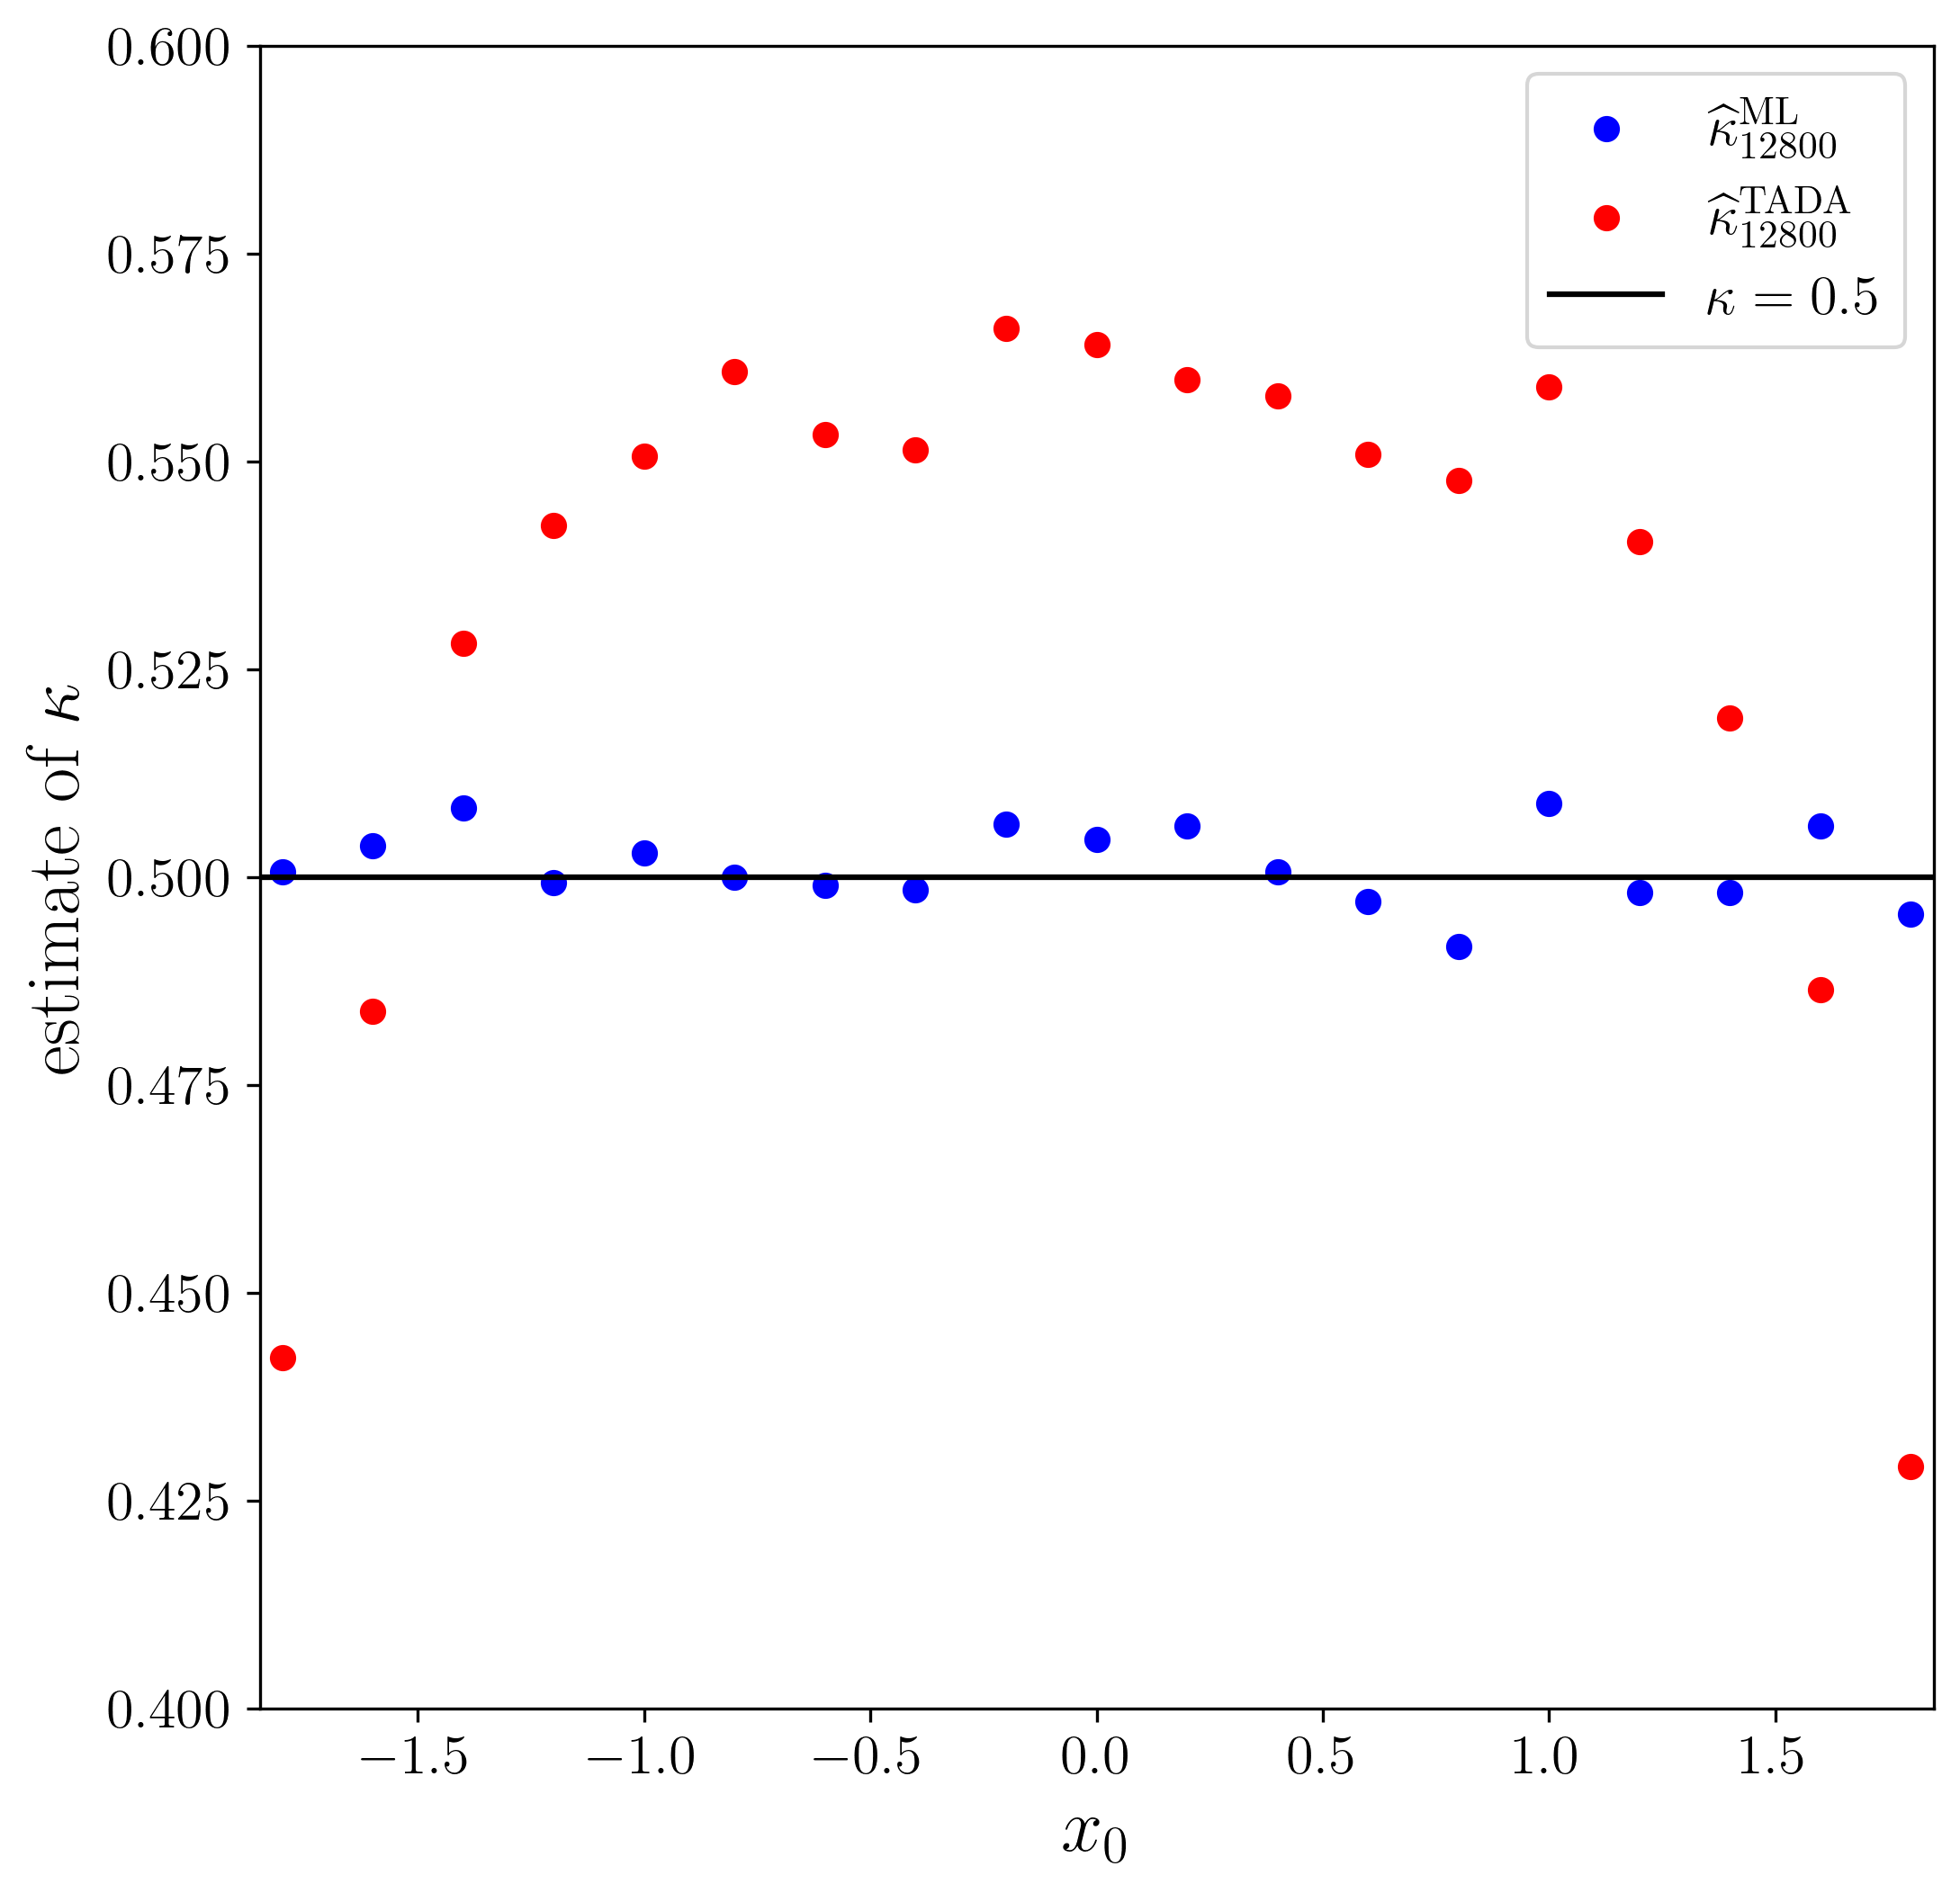

In [14]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=2, param_name=r"a",
    swept_idx=3, swept_name=r"x_0",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 2],
    xlim=(-1.85, 1.85), ylim=(1.8, 2.2),
)

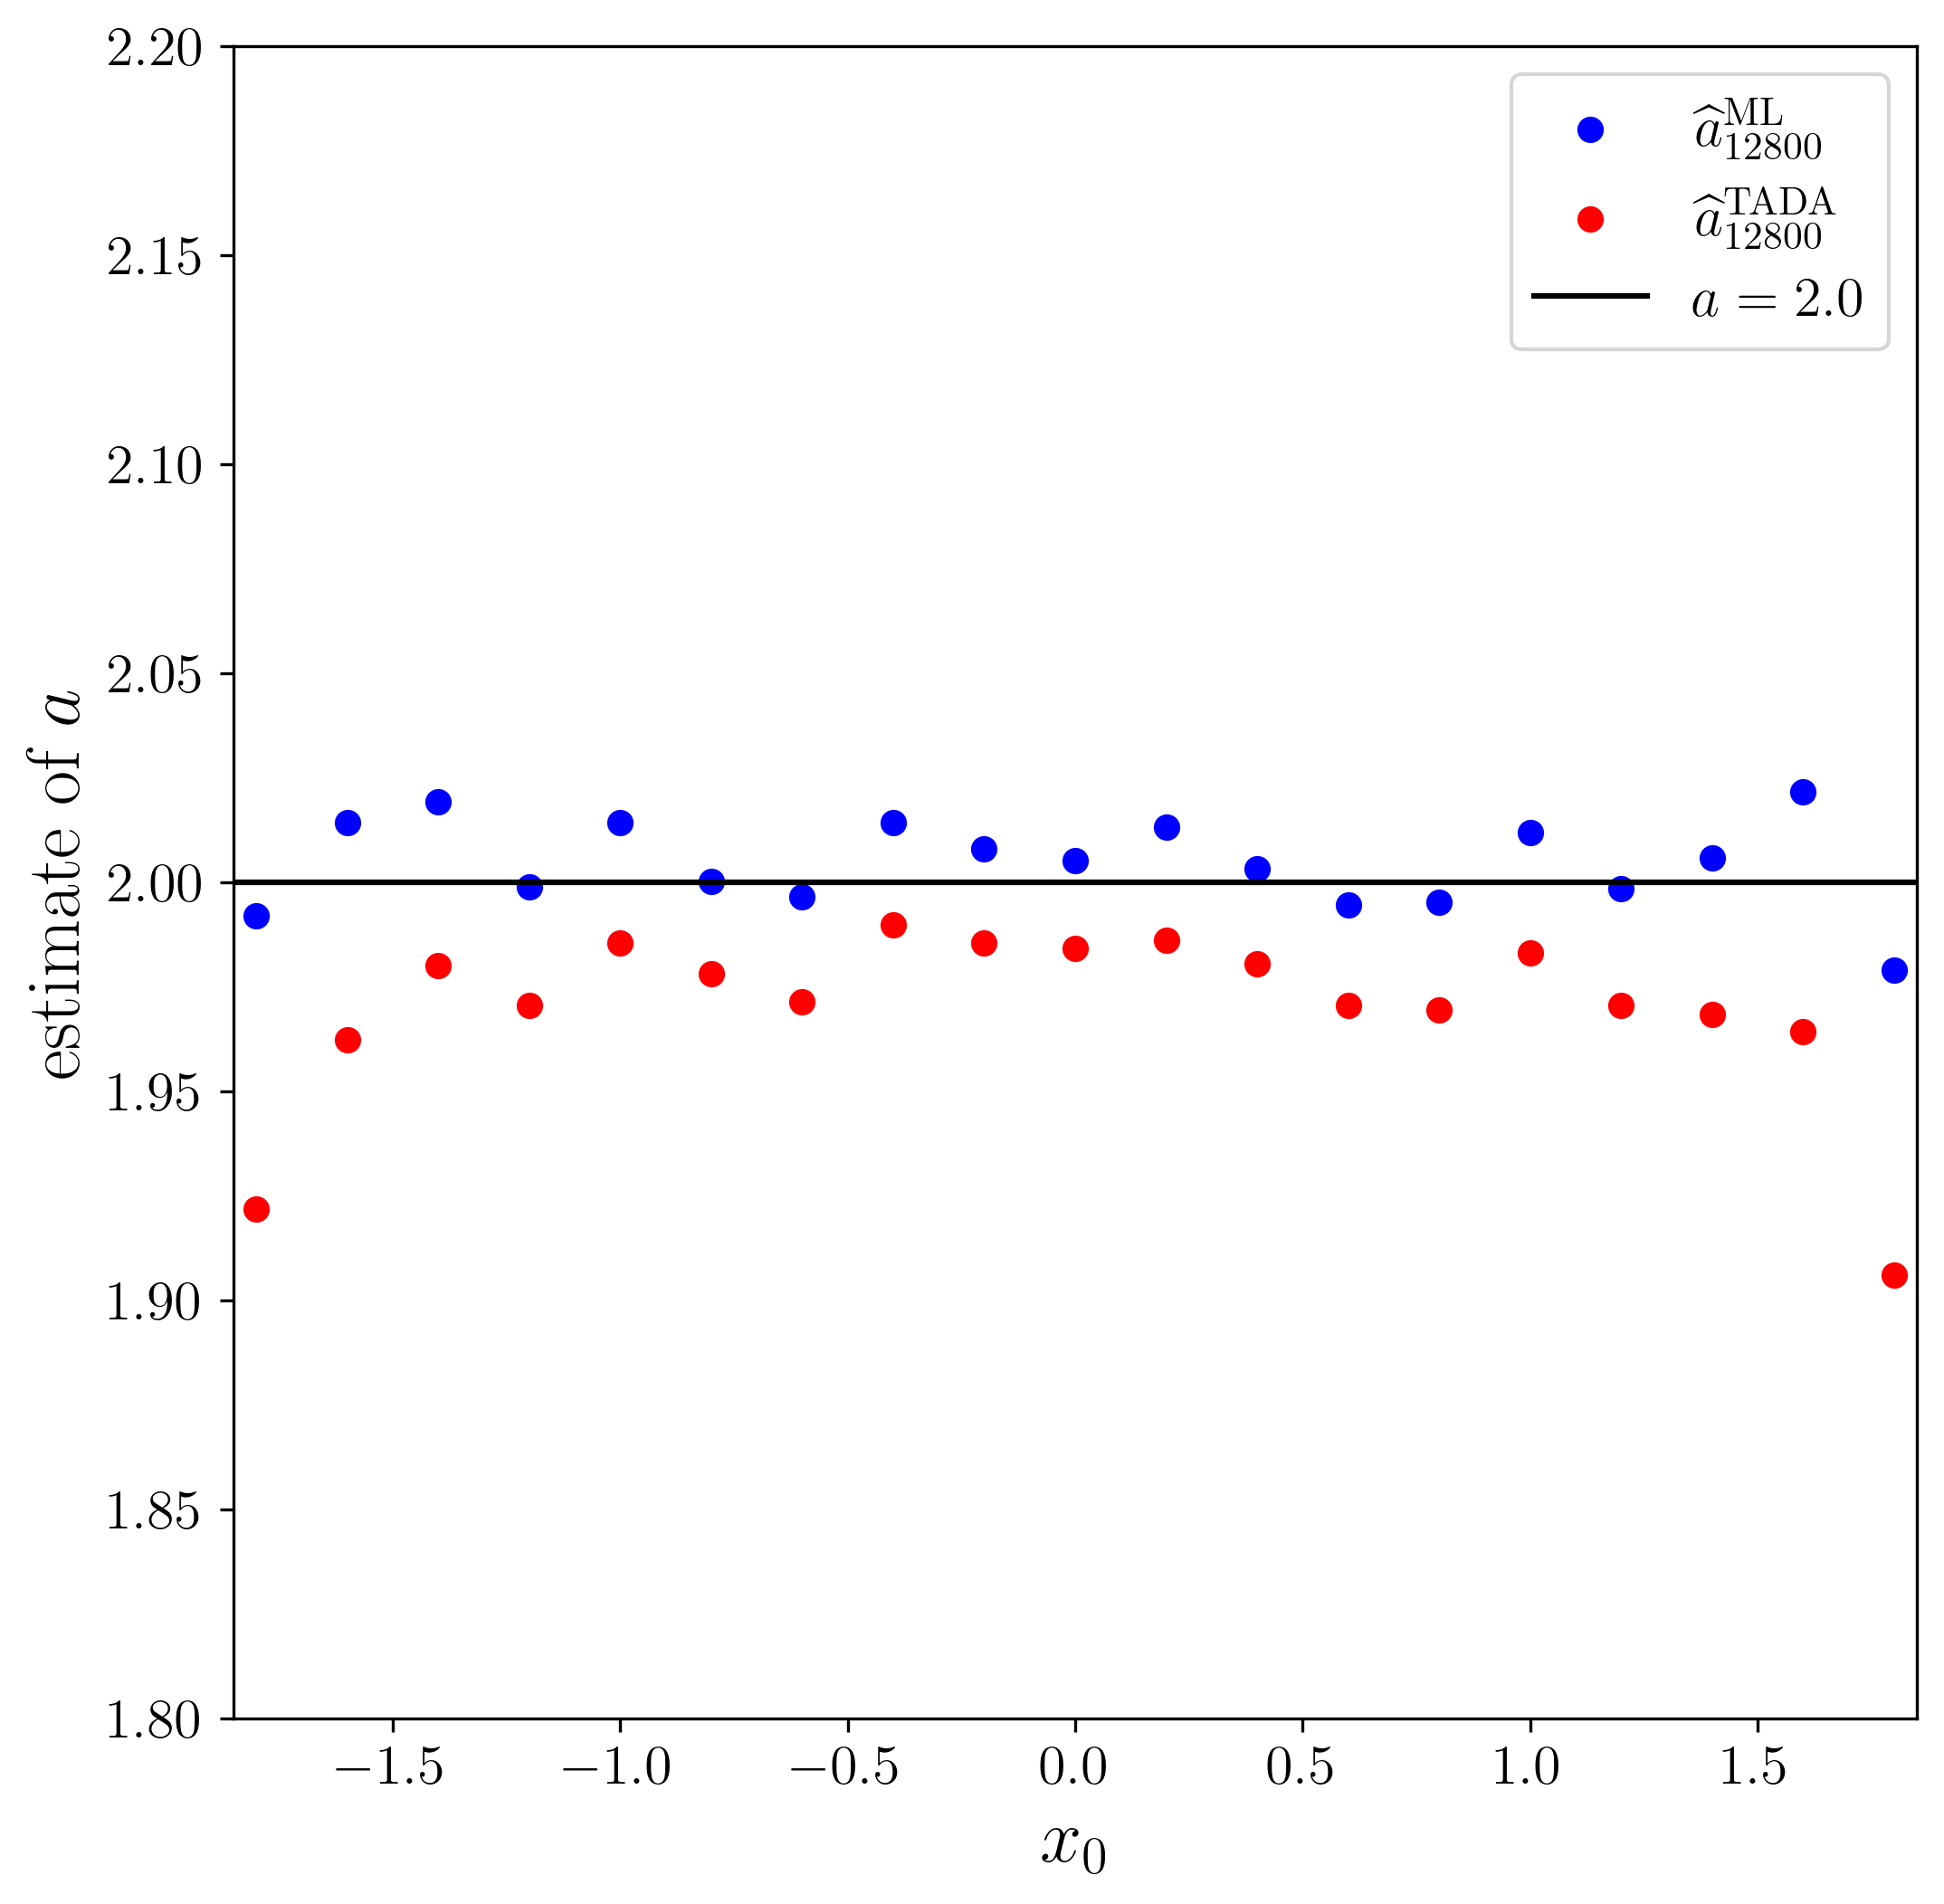

In [15]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=3, param_name=r"x_0",
    swept_idx=3, swept_name=r"x_0",
    num_data_list=num_data_list,
    identity_line=True,
    xlim=(-1.85, 1.85), ylim=(-1.85, 1.85),
)